# Titanic data analysis

First personal project in data analysis.

The goal is to analyze the data inside the CSV files, make some analysis and statistics starting from them.

I will start from importing the necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The first thing I want to know from this data is the shape and the informations inside. I will import the data as a pandas dataframe

In [3]:
data = pd.read_csv("train.csv")
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


There are 11 columns and 891 entries. There's some missing data in the age, cabin and embarked columns. We can start making some graphs to show for example the age and percentage of people survived.

I want to aggregate datas about age and make an istogram to show age distribution inside the titanic crew.

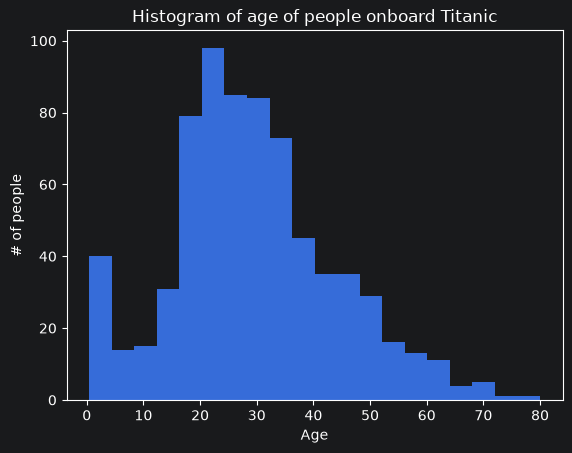

In [18]:
plt.hist(data["Age"], bins=20)
plt.title("Histogram of age of people onboard Titanic")
plt.xlabel("Age")
plt.ylabel("# of people")
plt.show()

I want to know how many people survived and how many died.

The idea is:
- isolate the column "survived", which i know has 891 non-null entries
- use the .count() function to know the # of dead and survived
- plot the data in a pie chart with respective percentages

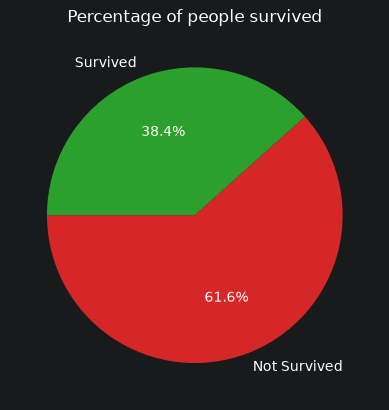

In [71]:
# s_rate = data["Survived"]
# survived = s_rate[s_rate == 1].count()
# not_survived = s_rate[s_rate == 0].count()

counts = data["Survived"].value_counts()

plt.pie(counts, labels=["Not Survived", "Survived"],
                                  autopct="%1.1f%%",
                                  colors=['#d62728', '#2ca02c'],
                                  startangle=180)
plt.title("Percentage of people survived")
plt.show()

Another thing I would like to know is the relationship between the survival rate and the age of people who survived and who didn't.

The strategy:
- create 2 data structures: I will select only the people who survived, and put the age in the first data structure. same thing with the people who didn't survive

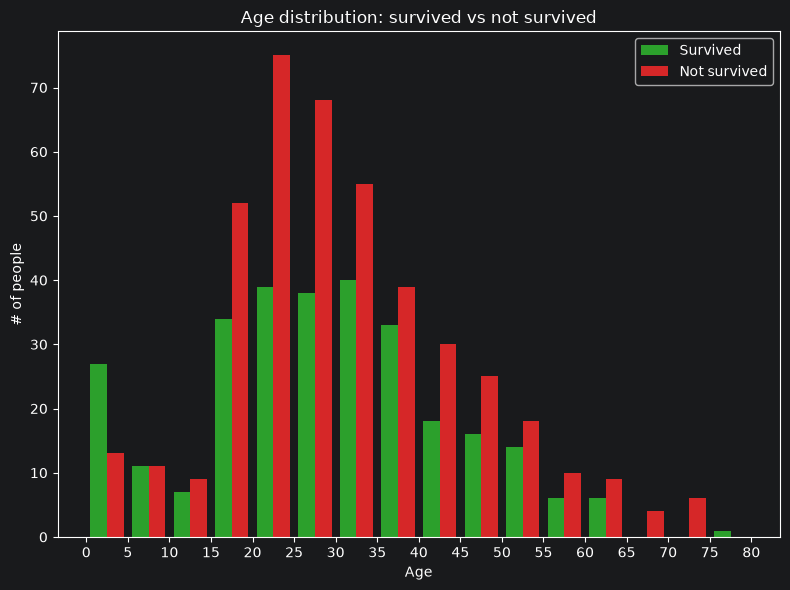

In [72]:
survived = data[data['Survived'] == True]
age_s = survived['Age']
n_survived = data[data['Survived'] == False]
age_ns =n_survived['Age']
edges = list(range(0, 85, 5))

plt.figure(figsize=(8, 6)) # aumento la dimensione della figura

plt.hist([age_s, age_ns], bins=edges, color=['#2ca02c', '#d62728'], label=['Survived', 'Not survived'])

plt.title("Age distribution: survived vs not survived")
plt.xlabel("Age")
plt.ylabel("# of people")
plt.legend()
plt.xticks(edges)
plt.tight_layout()
plt.show()